# Project: Identify Customer Segments

In this project, I applied unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Mail-Order Analytics Partner, and represents a real-life data science task.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Imputer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# produce visualizations in notebook
%matplotlib inline

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891,211 persons (rows) x 85 features (columns).
- `CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191,652 persons (rows) x 85 features (columns).
- `../docs/Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [2]:
# Load in the general demographics data.
azdias = pd.read_csv("../data/AZDIAS_Subset.csv", sep = ";")

# Load in the feature summary file.
feat_info = pd.read_csv("../data/AZDIAS_Feature_Summary.csv", sep = ";")

In [3]:
# Check the structure of the data after it's loaded

# There are 891,221 rows and 85 columns in the demographics data
# The varying numbers show that not all rows have values for every column
azdias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
AGER_TYP                 891221 non-null int64
ALTERSKATEGORIE_GROB     891221 non-null int64
ANREDE_KZ                891221 non-null int64
CJT_GESAMTTYP            886367 non-null float64
FINANZ_MINIMALIST        891221 non-null int64
FINANZ_SPARER            891221 non-null int64
FINANZ_VORSORGER         891221 non-null int64
FINANZ_ANLEGER           891221 non-null int64
FINANZ_UNAUFFAELLIGER    891221 non-null int64
FINANZ_HAUSBAUER         891221 non-null int64
FINANZTYP                891221 non-null int64
GEBURTSJAHR              891221 non-null int64
GFK_URLAUBERTYP          886367 non-null float64
GREEN_AVANTGARDE         891221 non-null int64
HEALTH_TYP               891221 non-null int64
LP_LEBENSPHASE_FEIN      886367 non-null float64
LP_LEBENSPHASE_GROB      886367 non-null float64
LP_FAMILIE_FEIN          886367 non-null float64
LP_FAMILIE_GROB          886367 n

In [4]:
# The varying stats show that not all rows have values for every column
# It also shows that the mean, std, max, min, and quartiles differ too
# Thus we can see this data is not normalized
azdias.describe()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,891221.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,...,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,794005.000000,794005.000000,794005.00000
mean,-0.358435,2.777398,1.522098,3.632838,3.074528,2.821039,3.401106,3.033328,2.874167,3.075121,...,2.253330,2.801858,1.595426,0.699166,1.943913,3.612821,3.381087,3.167854,5.293002,3.07222
std,1.198724,1.068775,0.499512,1.595021,1.321055,1.464749,1.322134,1.529603,1.486731,1.353248,...,0.972008,0.920309,0.986736,0.727137,1.459654,0.973967,1.111598,1.002376,2.303739,1.36298
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.00000
25%,-1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,1.000000,0.000000,1.000000,3.000000,3.000000,3.000000,4.000000,2.00000
50%,-1.000000,3.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,2.000000,3.000000,2.000000,1.000000,1.000000,4.000000,3.000000,3.000000,5.000000,3.00000
75%,-1.000000,4.000000,2.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,2.000000,1.000000,3.000000,4.000000,4.000000,4.000000,7.000000,4.00000
max,3.000000,9.000000,2.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,4.000000,4.000000,3.000000,2.000000,5.000000,5.000000,5.000000,9.000000,9.000000,9.00000


In [5]:
# Preview of first 5 rows
azdias.head(5)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [6]:
# Check the structure of the data after it's loaded

# This dataset provides info on the 85 columns of the demographics dataset
# Feat_info has 85 rows and 4 columns
feat_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
attribute             85 non-null object
information_level     85 non-null object
type                  85 non-null object
missing_or_unknown    85 non-null object
dtypes: object(4)
memory usage: 2.7+ KB


In [7]:
feat_info

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]
5,FINANZ_SPARER,person,ordinal,[-1]
6,FINANZ_VORSORGER,person,ordinal,[-1]
7,FINANZ_ANLEGER,person,ordinal,[-1]
8,FINANZ_UNAUFFAELLIGER,person,ordinal,[-1]
9,FINANZ_HAUSBAUER,person,ordinal,[-1]


## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

In [8]:
# turn missing_or_unknown to list 
feat_info['missing_or_unknown'] = feat_info['missing_or_unknown'].apply(lambda x: x[1:-1].split(','))

In [9]:
# Identify missing or unknown data values and convert them to NaNs.
for attrib, missing_values in zip(feat_info['attribute'], feat_info['missing_or_unknown']):
    if missing_values[0] != '':
        for value in missing_values:
            if value.isnumeric() or value.lstrip('-').isnumeric():
                value = int(value)
            azdias.loc[azdias[attrib] == value, attrib] = np.nan

In [10]:
azdias.to_csv('azdias_na.csv')

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [11]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

# Shape returns the max number of rows; count returns number of rows with values
azdias.shape[0] - azdias.count()

AGER_TYP                 685843
ALTERSKATEGORIE_GROB       2881
ANREDE_KZ                     0
CJT_GESAMTTYP              4854
FINANZ_MINIMALIST             0
FINANZ_SPARER                 0
FINANZ_VORSORGER              0
FINANZ_ANLEGER                0
FINANZ_UNAUFFAELLIGER         0
FINANZ_HAUSBAUER              0
FINANZTYP                     0
GEBURTSJAHR              392318
GFK_URLAUBERTYP            4854
GREEN_AVANTGARDE              0
HEALTH_TYP               111196
LP_LEBENSPHASE_FEIN       97632
LP_LEBENSPHASE_GROB       94572
LP_FAMILIE_FEIN           77792
LP_FAMILIE_GROB           77792
LP_STATUS_FEIN             4854
LP_STATUS_GROB             4854
NATIONALITAET_KZ         108315
PRAEGENDE_JUGENDJAHRE    108164
RETOURTYP_BK_S             4854
SEMIO_SOZ                     0
SEMIO_FAM                     0
SEMIO_REL                     0
SEMIO_MAT                     0
SEMIO_VERT                    0
SEMIO_LUST                    0
                          ...  
OST_WEST

In [12]:
# The average column has 98,517 missing entries
# The median is 93,148 so there is a right/positive skew

na_count = azdias.shape[0] - azdias.count()  
print("Mean:",np.mean(list(na_count)))
print("Median:",np.median(list(na_count)))

Mean: 98516.8117647
Median: 93148.0


(array([ 39.,  40.,   0.,   1.,   1.,   1.,   1.,   1.,   0.,   1.]),
 array([      0. ,   88906.1,  177812.2,  266718.3,  355624.4,  444530.5,
         533436.6,  622342.7,  711248.8,  800154.9,  889061. ]),
 <a list of 10 Patch objects>)

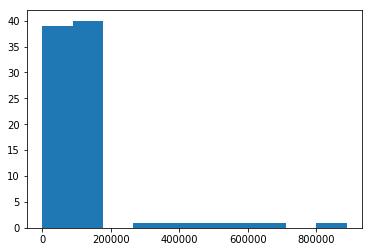

In [13]:
# Investigate patterns in the amount of missing data in each column.
na_count = pd.DataFrame(na_count)
na_count.columns=['na_count']
plt.hist(na_count['na_count'])

In [14]:
# Remove the outlier columns from the dataset.
na_count=na_count[na_count['na_count']>200000]
azdias=azdias.drop(na_count.index, axis = 1)

#### Discussion 1.1.2: Assess Missing Data in Each Column

Most of the NAs in each column is less than 200,000; thus, if a column has more than that, I am going to remove it. These columns are: 'AGER_TYP','GEBURTSJAHR','TITEL_KZ','ALTER_HH','KK_KUNDENTYP','KBA05_BAUMAX'.

Patterns in missing values:
1) LP_LEBENSPHASE_FEIN and LP_LEBENSPHASE_GROB, LP_FAMILIE_FEIN and LP_FAMILIE_GROB, LP_STATUS_FEIN and LP_STATUS_GROB, CAMEO_DEUG_2015 & CAMEO_DEU_2015 & CAMEO_INTL_2015 have the same number of missing values. They also represent similar information but in different scales; thus an option is to just keep one.

2) KBA05_ANTG1, KBA05_ANTG2, KBA05_ANTG3, and KBA05_ANTG4 also have the same number of missing values and represent info in the same geographical location. Likewise for PLZ8_ANTG1, PLZ8_ANTG2, PLZ8_ANTG3, PLZ8_ANTG4 PLZ8_BAUMAX, and PLZ8_HHZ&PLZ8_GBZ. A similar approach to 1 could also be taken.


#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

In [15]:
# How much data is missing in each row of the dataset?
azdias.shape[1]-azdias.count(axis=1)

0         43
1          0
2          0
3          7
4          0
5          0
6          0
7          0
8          0
9          0
10         0
11        47
12         6
13         8
14        47
15         8
16         6
17        47
18         3
19         0
20        10
21         0
22         0
23         8
24        47
25         5
26        19
27         0
28         0
29         2
          ..
891191     0
891192     0
891193     0
891194     0
891195     0
891196     0
891197     0
891198     0
891199     0
891200     0
891201     0
891202     0
891203    14
891204     0
891205     0
891206     0
891207     0
891208     3
891209     0
891210     0
891211     0
891212     0
891213     0
891214     0
891215     0
891216     3
891217     4
891218     5
891219     0
891220     0
Length: 891221, dtype: int64

(array([  6.97109000e+05,   7.76340000e+04,   1.28010000e+04,
          9.53300000e+03,   8.29000000e+02,   1.55000000e+02,
          1.40160000e+04,   5.03100000e+03,   2.80380000e+04,
          4.60750000e+04]),
 array([  0. ,   4.9,   9.8,  14.7,  19.6,  24.5,  29.4,  34.3,  39.2,
         44.1,  49. ]),
 <a list of 10 Patch objects>)

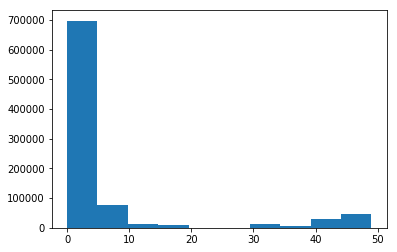

In [16]:
# Patterns in the amount of missing data in each row
na_count=pd.DataFrame(azdias.shape[1]-azdias.count(axis=1))
na_count.columns=['na_count']
plt.hist(na_count['na_count'])

In [17]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.
na_count1 = na_count[na_count['na_count']<30]
na_count2 = na_count[na_count['na_count']>=30]

azdias1=azdias.iloc[na_count1.index,:]
azdias2=azdias.iloc[na_count2.index,:]


<function matplotlib.pyplot.show(*args, **kw)>

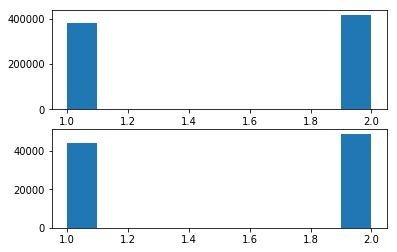

In [18]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

# Graph 1
fig1 = plt.figure()
ax1 = fig1.add_subplot(211)
ax1.hist(azdias1['ANREDE_KZ'])
ax2 = fig1.add_subplot(212)
ax2.hist(azdias2['ANREDE_KZ'])

plt.show

<function matplotlib.pyplot.show(*args, **kw)>

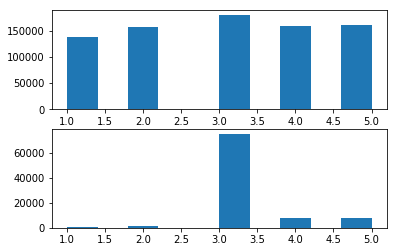

In [19]:
# Graph 2
fig1 = plt.figure()
ax1 = fig1.add_subplot(211)
ax1.hist(azdias1['FINANZ_MINIMALIST'])
ax2 = fig1.add_subplot(212)
ax2.hist(azdias2['FINANZ_MINIMALIST'])

plt.show

<function matplotlib.pyplot.show(*args, **kw)>

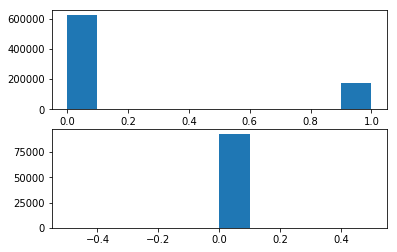

In [20]:
# Graph 3
fig1 = plt.figure()
ax1 = fig1.add_subplot(211)
ax1.hist(azdias1['GREEN_AVANTGARDE'])
ax2 = fig1.add_subplot(212)
ax2.hist(azdias2['GREEN_AVANTGARDE'])

plt.show

<function matplotlib.pyplot.show(*args, **kw)>

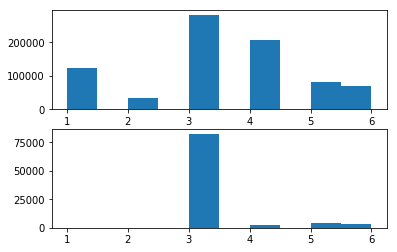

In [21]:
# Graph 4
fig1 = plt.figure()
ax1 = fig1.add_subplot(211)
ax1.hist(azdias1['ZABEOTYP'])
ax2 = fig1.add_subplot(212)
ax2.hist(azdias2['ZABEOTYP'])

plt.show

<function matplotlib.pyplot.show(*args, **kw)>

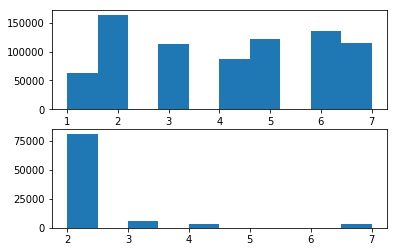

In [22]:
# Graph 5
fig1 = plt.figure()
ax1 = fig1.add_subplot(211)
ax1.hist(azdias1['SEMIO_SOZ'])
ax2 = fig1.add_subplot(212)
ax2.hist(azdias2['SEMIO_SOZ'])

plt.show

#### Discussion 1.1.3: Assess Missing Data in Each Row

Based on the distribution of values in the five columns where there are no NAs, the graph shows that the data subset that has lots of missing values usually has the same value in each column and the value is the same as the most frequent value of the data subset with less NAs. Therefore, I will remove the data subset that has a lot of missing values.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [23]:
# How many features are there of each data type?

# There are 21 categoricaly, 1 interval, 7 mixed,
# 7 numeric, and 49 ordinal
feat_info.groupby(['type'])['attribute'].count()

type
categorical    21
interval        1
mixed           7
numeric         7
ordinal        49
Name: attribute, dtype: int64

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [24]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?
azdias.iloc[:,feat_info[feat_info['type']=='categorical'].index].apply(pd.value_counts,axis=0).fillna(0)

/opt/conda/lib/python3.6/site-packages/pandas/core/indexes/api.py:107: RuntimeWarning: '<' not supported between instances of 'float' and 'str', sort order is undefined for incomparable objects
  result = result.union(other)
/opt/conda/lib/python3.6/site-packages/pandas/core/indexes/api.py:107: RuntimeWarning: '>' not supported between instances of 'str' and 'float', sort order is undefined for incomparable objects
  result = result.union(other)


,ALTERSKATEGORIE_GROB,CJT_GESAMTTYP,FINANZ_MINIMALIST,GFK_URLAUBERTYP,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,...,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,GEBAEUDETYP,CAMEO_DEUG_2015,KBA05_ANTG1,KBA05_ANTG3,KBA05_ANTG4
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,34103.0,814542.0,0.0,0.0,0.0,261049.0,511545.0,600171.0
1.0,142887.0,98869.0,139587.0,53600.0,162388.0,62667.0,219275.0,337511.0,684085.0,21282.0,...,381303.0,123622.0,423383.0,2970.0,53232.0,460465.0,0.0,161224.0,92748.0,83591.0
2.0,158410.0,148795.0,159313.0,46702.0,306944.0,39434.0,118236.0,226915.0,65418.0,7479.0,...,398722.0,33170.0,195470.0,202.0,140817.0,4935.0,0.0,126725.0,80234.0,74135.0
3.0,358533.0,156449.0,256276.0,56007.0,310693.0,19985.0,74105.0,40973.0,33403.0,55195.0,...,0.0,364905.0,94905.0,5.0,84805.0,178668.0,0.0,117762.0,73370.0,0.0
4.0,228510.0,210963.0,167182.0,63770.0,0.0,17595.0,78317.0,162946.0,0.0,20451.0,...,0.0,210095.0,47126.0,2.0,139762.0,900.0,0.0,91137.0,0.0,0.0
5.0,0.0,117376.0,168863.0,120126.0,0.0,55542.0,74493.0,118022.0,0.0,86416.0,...,0.0,84956.0,15503.0,0.0,201482.0,1.0,0.0,0.0,0.0,0.0
6.0,0.0,153915.0,0.0,27138.0,0.0,45614.0,30914.0,0.0,0.0,25652.0,...,0.0,74473.0,4842.0,1.0,252775.0,628.0,0.0,0.0,0.0,0.0
7.0,0.0,0.0,0.0,42956.0,0.0,26508.0,10059.0,0.0,0.0,4010.0,...,0.0,0.0,1525.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8.0,0.0,0.0,0.0,88042.0,0.0,30475.0,19708.0,0.0,0.0,145988.0,...,0.0,0.0,523.0,0.0,0.0,152476.0,0.0,0.0,0.0,0.0
9.0,0.0,0.0,0.0,60614.0,0.0,13066.0,143238.0,0.0,0.0,33570.0,...,0.0,0.0,180.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Re-encode categorical variable(s) to be kept in the analysis.
azdias = pd.read_csv('azdias_na.csv')

azdias.loc[azdias['OST_WEST_KZ']=='W','OST_WEST_KZ']=0
azdias.loc[azdias['OST_WEST_KZ']=='O','OST_WEST_KZ']=1

#### Discussion 1.2.1: Re-Encode Categorical Features

I removed the categorical variables that has more than 10 levels:'GFK_URLAUBERTYP','LP_FAMILIE_FEIN','CAMEO_DEU_2015' 

Re-encoded categorical variable: OST_WEST_KZ 

Re-engineered: one hot encoding with the left categorical variables

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `../docs/Data_Dictionary.md` for the details needed to finish these tasks.

In [26]:
# Investigate "PRAEGENDE_JUGENDJAHRE" (Praegende Teens) and engineer two new variables.

azdias['PRAEGENDE_JUGENDJAHRE'].value_counts()

# Create new variable 'WHETHER_MAINTSTREAM'
azdias.loc[azdias['PRAEGENDE_JUGENDJAHRE'].isin([1,3,5,8,10,12,14]),'WHETHER_MAINSTREAM']=1
azdias.loc[azdias['PRAEGENDE_JUGENDJAHRE'].isin([2,4,6,7,9,11,13,15]),'WHETHER_MAINSTREAM']=2

# Create new variable 'Region': East-1, West-2, EAST+WEST-3
azdias.loc[azdias['PRAEGENDE_JUGENDJAHRE'].isin([7,12,13]),'REGION']=1
azdias.loc[azdias['PRAEGENDE_JUGENDJAHRE'].isin([6,10,11]),'REGION']=2
azdias.loc[azdias['PRAEGENDE_JUGENDJAHRE'].isin([1,2,3,4,5,8,9,14,15]),'REGION']=3

# Drop Original Column
azdias=azdias.drop('PRAEGENDE_JUGENDJAHRE',axis=1)

In [27]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

azdias['CAMEO_INTL_2015'].value_counts()
azdias['CAMEO_INTL_2015']=azdias['CAMEO_INTL_2015'].astype(float)

# Create New Variable: 'HOUSEHOLD_WEALTH'
azdias.loc[azdias['CAMEO_INTL_2015'].isin([51,52,53,54,55]),'HOUSEHOLD_WEALTH']=1
azdias.loc[azdias['CAMEO_INTL_2015'].isin([41,42,43,44,45]),'HOUSEHOLD_WEALTH']=2
azdias.loc[azdias['CAMEO_INTL_2015'].isin([31,32,33,34,35]),'HOUSEHOLD_WEALTH']=3
azdias.loc[azdias['CAMEO_INTL_2015'].isin([21,22,23,24,25]),'HOUSEHOLD_WEALTH']=4
azdias.loc[azdias['CAMEO_INTL_2015'].isin([11,12,13,14,15]),'HOUSEHOLD_WEALTH']=5

# Create New Variable: 'HOUSEHOLD_LIFE_STAGE'
azdias.loc[azdias['CAMEO_INTL_2015'].isin([11,21,31,41,51]),'HOUSEHOLD_LIFE_STAGE']=1
azdias.loc[azdias['CAMEO_INTL_2015'].isin([12,22,32,42,52]),'HOUSEHOLD_LIFE_STAGE']=2
azdias.loc[azdias['CAMEO_INTL_2015'].isin([13,23,33,43,53]),'HOUSEHOLD_LIFE_STAGE']=3
azdias.loc[azdias['CAMEO_INTL_2015'].isin([14,24,34,44,54]),'HOUSEHOLD_LIFE_STAGE']=4
azdias.loc[azdias['CAMEO_INTL_2015'].isin([15,25,35,45,55]),'HOUSEHOLD_LIFE_STAGE']=5

# Drop Original Column
azdias=azdias.drop('CAMEO_INTL_2015',axis=1)

#### Discussion 1.2.2: Engineer Mixed-Type Features

I removed LP_LEBENSPHASE_FEIN and LP_LEBENSPHASE_GROB because, according to data dictionary, these 2 variables represent personal age level, salary level and household type; which other varibales already contain this information.

Kept: PRAEGENDE_JUGENDJAHRE, CAMEO_INTL_2015, CAMEO_INTL_2015
Dropped: WOHNLAGE, PLZ8_BAUMAX, KBA05_BAUMAX

Re-encoded: PRAEGENDE_JUGENDJAHRE, CAMEO_INTL_2015

In [28]:
# Remove mixed categorical variables
azdias=azdias.drop(['LP_LEBENSPHASE_FEIN','LP_LEBENSPHASE_GROB'],axis=1)

# Remove Variables
azdias=azdias.drop(['WOHNLAGE','PLZ8_BAUMAX','KBA05_BAUMAX'],axis=1)

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [29]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

azdias=azdias.drop(['GFK_URLAUBERTYP','LP_FAMILIE_FEIN','CAMEO_DEU_2015'],axis=1)

# Remove variables have too many NAs (more than 200,000)
azdias=azdias.drop(['AGER_TYP','GEBURTSJAHR','TITEL_KZ','ALTER_HH','KK_KUNDENTYP'],axis=1)

In [30]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.


# Remove rows that have too many NAs (>= 30)
na_count=pd.DataFrame(azdias.shape[1]-azdias.count(axis=1))
na_count.columns=['na_count']

na_count=na_count[na_count['na_count']>=30]

azdias_missing=azdias.loc[na_count.index,:]
azdias=azdias.drop(na_count.index)

### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [31]:
def clean_data(df):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    # Identify missing or unknown data values and convert them to NaNs.
    for attrib, missing_values in zip(feat_info['attribute'], feat_info['missing_or_unknown']):
        if missing_values[0] != '':
            for value in missing_values:
                if value.isnumeric() or value.lstrip('-').isnumeric():
                    value = int(value)
                df.loc[df[attrib] == value, attrib] = np.nan
    
    df.iloc[:,feat_info[feat_info['type']=='categorical'].index].apply(pd.value_counts,axis=0).fillna(0)
    
    df.loc[df['OST_WEST_KZ']=='W','OST_WEST_KZ']=0
    df.loc[df['OST_WEST_KZ']=='O','OST_WEST_KZ']=1
    
    # Create new variable 'WHETHER_MAINTSTREAM'
    df.loc[df['PRAEGENDE_JUGENDJAHRE'].isin([1,3,5,8,10,12,14]),'WHETHER_MAINSTREAM']=1
    df.loc[df['PRAEGENDE_JUGENDJAHRE'].isin([2,4,6,7,9,11,13,15]),'WHETHER_MAINSTREAM']=2

    df.loc[df['PRAEGENDE_JUGENDJAHRE'].isin([7,12,13]),'REGION']=1
    df.loc[df['PRAEGENDE_JUGENDJAHRE'].isin([6,10,11]),'REGION']=2
    df.loc[df['PRAEGENDE_JUGENDJAHRE'].isin([1,2,3,4,5,8,9,14,15]),'REGION']=3

    df=df.drop('PRAEGENDE_JUGENDJAHRE',axis=1)
    
    df['CAMEO_INTL_2015'].value_counts()
    df['CAMEO_INTL_2015']=df['CAMEO_INTL_2015'].astype(float)

    df.loc[df['CAMEO_INTL_2015'].isin([51,52,53,54,55]),'HOUSEHOLD_WEALTH']=1
    df.loc[df['CAMEO_INTL_2015'].isin([41,42,43,44,45]),'HOUSEHOLD_WEALTH']=2
    df.loc[df['CAMEO_INTL_2015'].isin([31,32,33,34,35]),'HOUSEHOLD_WEALTH']=3
    df.loc[df['CAMEO_INTL_2015'].isin([21,22,23,24,25]),'HOUSEHOLD_WEALTH']=4
    df.loc[df['CAMEO_INTL_2015'].isin([11,12,13,14,15]),'HOUSEHOLD_WEALTH']=5

    df.loc[df['CAMEO_INTL_2015'].isin([11,21,31,41,51]),'HOUSEHOLD_LIFE_STAGE']=1
    df.loc[df['CAMEO_INTL_2015'].isin([12,22,32,42,52]),'HOUSEHOLD_LIFE_STAGE']=2
    df.loc[df['CAMEO_INTL_2015'].isin([13,23,33,43,53]),'HOUSEHOLD_LIFE_STAGE']=3
    df.loc[df['CAMEO_INTL_2015'].isin([14,24,34,44,54]),'HOUSEHOLD_LIFE_STAGE']=4
    df.loc[df['CAMEO_INTL_2015'].isin([15,25,35,45,55]),'HOUSEHOLD_LIFE_STAGE']=5

    df=df.drop('CAMEO_INTL_2015',axis=1)
    
    df=df.drop(['LP_LEBENSPHASE_FEIN','LP_LEBENSPHASE_GROB'],axis=1)

    df=df.drop(['WOHNLAGE','PLZ8_BAUMAX','KBA05_BAUMAX'],axis=1)
    
    df=df.drop(['GFK_URLAUBERTYP','LP_FAMILIE_FEIN','CAMEO_DEU_2015'],axis=1)

    df=df.drop(['AGER_TYP','GEBURTSJAHR','TITEL_KZ','ALTER_HH','KK_KUNDENTYP'],axis=1)
    
    na_count=pd.DataFrame(df.shape[1]-df.count(axis=1))
    na_count.columns=['na_count']

    na_count=na_count[na_count['na_count']>=30]

    df_missing=df.loc[na_count.index,:]
    df=df.drop(na_count.index)

    # Numeric NAs were replaced with median
    imp1 = Imputer(missing_values=np.nan, strategy='median', axis=0)
    df[['ANZ_PERSONEN','ANZ_TITEL','ANZ_HAUSHALTE_AKTIV',
        'ANZ_HH_TITEL','MIN_GEBAEUDEJAHR','KBA13_ANZAHL_PKW']]=imp1.fit_transform(df[['ANZ_PERSONEN','ANZ_TITEL','ANZ_HAUSHALTE_AKTIV','ANZ_HH_TITEL','MIN_GEBAEUDEJAHR','KBA13_ANZAHL_PKW']])

    imp2 = Imputer(missing_values=np.nan, strategy='most_frequent', axis=0)
    df[['SHOPPER_TYP','SOHO_KZ','KBA05_ANTG1','KBA05_ANTG2','KBA05_ANTG3',
       'KBA05_ANTG4','ONLINE_AFFINITAET','PLZ8_ANTG1','PLZ8_ANTG2',
       'PLZ8_ANTG3','PLZ8_ANTG4']]=imp2.fit_transform(df[[
    'SHOPPER_TYP','SOHO_KZ','KBA05_ANTG1','KBA05_ANTG2','KBA05_ANTG3',
       'KBA05_ANTG4','ONLINE_AFFINITAET','PLZ8_ANTG1','PLZ8_ANTG2',
       'PLZ8_ANTG3','PLZ8_ANTG4']])

    df=df.fillna(0)
    
    categorical_features=feat_info.loc[feat_info['type']=='categorical','attribute']
    categorical_features=pd.concat([categorical_features,pd.Series(['WHETHER_MAINSTREAM','REGION','HOUSEHOLD_WEALTH','HOUSEHOLD_LIFE_STAGE'])])
    categorical_features2=categorical_features[categorical_features.isin(list(df.columns))]

    df_cat=df[categorical_features2]

    df_cat_dummies=df_cat
    for a in df_cat.columns:
        df_cat[a]=pd.Categorical(df_cat[a])
        dfDummies = pd.get_dummies(df_cat[a], prefix = a)
        df_cat_dummies = pd.concat([df_cat_dummies, dfDummies], axis=1)

    df_cat_dummies =df_cat_dummies.drop(categorical_features2,axis=1)

    df_noncat=df.drop(categorical_features2,axis=1)

    df=pd.concat([df_noncat, df_cat_dummies], axis=1)

    return df

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [32]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

# Numeric NAs were replaced with median
imp1 = Imputer(missing_values=np.nan, strategy='median', axis=0)
azdias[['ANZ_PERSONEN','ANZ_TITEL','ANZ_HAUSHALTE_AKTIV',
        'ANZ_HH_TITEL','MIN_GEBAEUDEJAHR','KBA13_ANZAHL_PKW']]=imp1.fit_transform(azdias[['ANZ_PERSONEN','ANZ_TITEL','ANZ_HAUSHALTE_AKTIV','ANZ_HH_TITEL','MIN_GEBAEUDEJAHR','KBA13_ANZAHL_PKW']])

# Categorical variables having 0 in their values had NAs replaced with most
# frequent item
imp2 = Imputer(missing_values=np.nan, strategy='most_frequent', axis=0)
azdias[['SHOPPER_TYP','SOHO_KZ','KBA05_ANTG1','KBA05_ANTG2','KBA05_ANTG3',
       'KBA05_ANTG4','ONLINE_AFFINITAET','PLZ8_ANTG1','PLZ8_ANTG2',
       'PLZ8_ANTG3','PLZ8_ANTG4']]=imp2.fit_transform(azdias[[
    'SHOPPER_TYP','SOHO_KZ','KBA05_ANTG1','KBA05_ANTG2','KBA05_ANTG3',
       'KBA05_ANTG4','ONLINE_AFFINITAET','PLZ8_ANTG1','PLZ8_ANTG2',
       'PLZ8_ANTG3','PLZ8_ANTG4']])

# Categorial Variables without 0 in their values, 0 replaces NAs
azdias=azdias.fillna(0)

In [33]:
categorical_features=feat_info.loc[feat_info['type']=='categorical','attribute']
categorical_features=pd.concat([categorical_features,pd.Series(['WHETHER_MAINSTREAM','REGION','HOUSEHOLD_WEALTH','HOUSEHOLD_LIFE_STAGE'])])
categorical_features2=categorical_features[categorical_features.isin(list(azdias.columns))]

azdias_cat=azdias[categorical_features2]

# One Hot Encoding
azdias_cat_dummies=azdias_cat
for a in azdias_cat.columns:
    azdias_cat[a]=pd.Categorical(azdias_cat[a])
    dfDummies = pd.get_dummies(azdias_cat[a], prefix = a)
    azdias_cat_dummies = pd.concat([azdias_cat_dummies, dfDummies], axis=1)

azdias_cat_dummies =azdias_cat_dummies.drop(categorical_features2,axis=1)

azdias_noncat=azdias.drop(categorical_features2,axis=1)

azdias2=pd.concat([azdias_noncat, azdias_cat_dummies], axis=1)


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.


In [34]:
azdias2.head()

,Unnamed: 0,ALTERSKATEGORIE_GROB,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,HEALTH_TYP,RETOURTYP_BK_S,...,HOUSEHOLD_WEALTH_2.0,HOUSEHOLD_WEALTH_3.0,HOUSEHOLD_WEALTH_4.0,HOUSEHOLD_WEALTH_5.0,HOUSEHOLD_LIFE_STAGE_0.0,HOUSEHOLD_LIFE_STAGE_1.0,HOUSEHOLD_LIFE_STAGE_2.0,HOUSEHOLD_LIFE_STAGE_3.0,HOUSEHOLD_LIFE_STAGE_4.0,HOUSEHOLD_LIFE_STAGE_5.0
1,1,1.0,1.0,5.0,2.0,5.0,4.0,5.0,3.0,1.0,...,0,0,0,0,0,1,0,0,0,0
2,2,3.0,1.0,4.0,1.0,2.0,3.0,5.0,3.0,3.0,...,0,0,1,0,0,0,0,0,1,0
3,3,4.0,4.0,2.0,5.0,2.0,1.0,2.0,2.0,2.0,...,0,0,0,1,0,0,1,0,0,0
4,4,3.0,4.0,3.0,4.0,1.0,3.0,2.0,3.0,5.0,...,1,0,0,0,0,0,0,1,0,0
5,5,1.0,3.0,1.0,5.0,2.0,2.0,5.0,3.0,3.0,...,0,0,0,0,0,0,0,0,1,0


In [35]:
azdias2.info(152)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 798071 entries, 1 to 891220
Data columns (total 153 columns):
Unnamed: 0                  int64
ALTERSKATEGORIE_GROB        float64
FINANZ_MINIMALIST           float64
FINANZ_SPARER               float64
FINANZ_VORSORGER            float64
FINANZ_ANLEGER              float64
FINANZ_UNAUFFAELLIGER       float64
FINANZ_HAUSBAUER            float64
HEALTH_TYP                  float64
RETOURTYP_BK_S              float64
SEMIO_SOZ                   float64
SEMIO_FAM                   float64
SEMIO_REL                   float64
SEMIO_MAT                   float64
SEMIO_VERT                  float64
SEMIO_LUST                  float64
SEMIO_ERL                   float64
SEMIO_KULT                  float64
SEMIO_RAT                   float64
SEMIO_KRIT                  float64
SEMIO_DOM                   float64
SEMIO_KAEM                  float64
SEMIO_PFLICHT               float64
SEMIO_TRADV                 float64
ANZ_PERSONEN              

In [36]:
# Apply feature scaling to the general population demographics data.
scaler = StandardScaler()
azdias3= scaler.fit_transform(azdias2)
azdias3=pd.DataFrame(azdias3)
azdias3.columns=azdias2.columns

### Discussion 2.1: Apply Feature Scaling

Regarding NAs imputation strategy, I used median instead of mean to impute the NAs becaue all of the numberic variables are integers and means would bring float numbers into the dataset.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [37]:
# Apply PCA to the data.

pca = PCA()
azdias_pca = pca.fit_transform(azdias3)

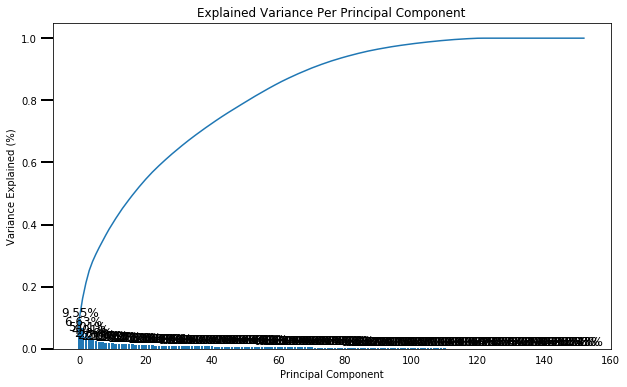

In [38]:
# Investigate the variance accounted for by each principal component.

def scree_plot(pca):
    num_components = len(pca.explained_variance_ratio_)
    ind = np.arange(num_components)
    vals = pca.explained_variance_ratio_
    
    plt.figure(figsize=(10,6))
    ax = plt.subplot(111)
    cumvals = np.cumsum(vals)
    ax.bar(ind,vals)
    ax.plot(ind, cumvals)
    for i in range(num_components):
        ax.annotate(r"%s%%" % ((str(vals[i]*100)[:4])), (ind[i]+0.2,
                     vals[i]), va="bottom", ha="center", fontsize=12)
        
    ax.xaxis.set_tick_params(width=0)
    ax.yaxis.set_tick_params(width=2, length=12)
    
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    plt.title('Explained Variance Per Principal Component')
    
scree_plot(pca)


In [39]:
# Re-apply PCA to the data while selecting for number of components to retain.
pca = PCA(n_components = 60)
azdias_pca = pca.fit_transform(azdias3)

### Discussion 2.2: Perform Dimensionality Reduction

I chose 60 components for the next step for the analysis because when n_components equals 60, the variance explained is close to 90%.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [40]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

df=pd.DataFrame(pca.components_[0])
df.index=azdias3.columns
df.columns=['PC_1']
df=df.sort_index(by=['PC_1'], ascending=False)
df

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:9: FutureWarning: by argument to sort_index is deprecated, please use .sort_values(by=...)
  if __name__ == '__main__':


,PC_1
LP_STATUS_GROB_1.0,0.202469
HH_EINKOMMEN_SCORE,0.194062
PLZ8_ANTG3,0.182650
PLZ8_ANTG4,0.175766
FINANZ_HAUSBAUER,0.156193
HOUSEHOLD_WEALTH_1.0,0.154286
ORTSGR_KLS9,0.151114
EWDICHTE,0.150940
HOUSEHOLD_LIFE_STAGE_1.0,0.142453
LP_STATUS_FEIN_1.0,0.131166


In [41]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

df=pd.DataFrame(pca.components_[1])
df.index=azdias3.columns
df.columns=['PC_2']
df=df.sort_index(by=['PC_2'],ascending=False)
df

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:7: FutureWarning: by argument to sort_index is deprecated, please use .sort_values(by=...)
  import sys


,PC_2
ALTERSKATEGORIE_GROB,0.240389
FINANZ_VORSORGER,0.220896
ZABEOTYP_3.0,0.211301
SEMIO_ERL,0.210835
SEMIO_LUST,0.166913
RETOURTYP_BK_S,0.150344
CJT_GESAMTTYP_2.0,0.113596
SEMIO_KRIT,0.103210
W_KEIT_KIND_HH,0.099748
LP_STATUS_FEIN_1.0,0.097576


In [42]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

df=pd.DataFrame(pca.components_[2])
df.index=azdias3.columns
df.columns=['PC_3']
df=df.sort_index(by=['PC_3'], ascending=False)
df


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:7: FutureWarning: by argument to sort_index is deprecated, please use .sort_values(by=...)
  import sys


,PC_3
ANREDE_KZ_1.0,0.320122
SEMIO_VERT,0.295536
SEMIO_SOZ,0.232108
SEMIO_FAM,0.220103
SEMIO_KULT,0.211173
FINANZTYP_5.0,0.137427
FINANZ_MINIMALIST,0.125223
SHOPPER_TYP_0.0,0.103985
ZABEOTYP_1.0,0.089035
RETOURTYP_BK_S,0.086024


### Discussion 2.3: Interpret Principal Components

Principal Component 1, PC_1, is about personal income and family capacity based on the features of LP_STATUS_GROB_1, FINANZ_SPARER, FINANZ_HAUSBAUER, PLZ8_ANTG3, and PLZ_ANTG4. In contrast, some strong negative feature weights are FINANZ_MINIMALIST and KBA05_ANTG1, which indicate the prevalence of buildings with smaller family capacity and financial typology. This suggests that the feature is about wealth and the family size.

PC_2 is about household income and community unemployment rate. Some strong negative feature weights are HH_EINKOMMEN_SCORE, ARBEIT, ORTSGR_KLS9, and RELAT_AB, which indicate the prevalence of smaller community size, lower unemployment rate and higher household income.

PC_3 is about age and personality typology based on the feature of ALTERSKATEGORIE_GROB, SEMIO_ERL, SEMIO_LUST, and SEMIO_KRIT. Some strong negative features are SEMIO_KULT, SEMIO_TRADV, SEMIO_REL, which indicate more conservative personality. This suggests that this feature is related to age.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

Text(0.5,1,'SSE vs. K')

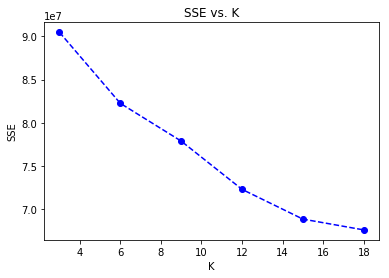

In [43]:
# Over a number of different cluster counts...
    # run k-means clustering on the data and...
    # compute the average within-cluster distances. 
# Investigate the change in within-cluster distance across number of clusters.
def get_kmeans_score(data, center):
    kmeans = KMeans(n_clusters=center)
    model = kmeans.fit(data)
    score = np.abs(model.score(data))
    return score

scores = []
centers = list(range(3,20,3))

for center in centers:
    scores.append(get_kmeans_score(azdias_pca, center))
    
plt.plot(centers, scores, linestyle='--', marker='o', color='b');
plt.xlabel('K');
plt.ylabel('SSE');
plt.title('SSE vs. K')

In [44]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.


kmeans = KMeans(n_clusters=15, random_state=0).fit(azdias_pca)
prediction = kmeans.predict(azdias_pca)


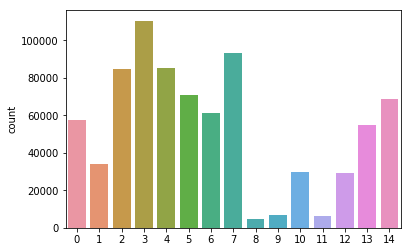

In [45]:
sns.countplot(prediction)

### Discussion 3.1: Apply Clustering to General Population

The average distance within the cluster keeps decreasing as the number of clusters increases. However, considering the large volumn of dataset and time of computation, I decide to choose 15 clusters.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [46]:
azdias3.info(152)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798071 entries, 0 to 798070
Data columns (total 153 columns):
Unnamed: 0                  float64
ALTERSKATEGORIE_GROB        float64
FINANZ_MINIMALIST           float64
FINANZ_SPARER               float64
FINANZ_VORSORGER            float64
FINANZ_ANLEGER              float64
FINANZ_UNAUFFAELLIGER       float64
FINANZ_HAUSBAUER            float64
HEALTH_TYP                  float64
RETOURTYP_BK_S              float64
SEMIO_SOZ                   float64
SEMIO_FAM                   float64
SEMIO_REL                   float64
SEMIO_MAT                   float64
SEMIO_VERT                  float64
SEMIO_LUST                  float64
SEMIO_ERL                   float64
SEMIO_KULT                  float64
SEMIO_RAT                   float64
SEMIO_KRIT                  float64
SEMIO_DOM                   float64
SEMIO_KAEM                  float64
SEMIO_PFLICHT               float64
SEMIO_TRADV                 float64
ANZ_PERSONEN            

In [47]:
# need to make the columns for the customer and population datasets match
def add_missing_dummy_columns(d, columns):
    missing_cols = set(columns) - set(d.columns)
    print(missing_cols)
    for c in missing_cols:
        d[c] = 0

def fix_columns(d, columns):  
    add_missing_dummy_columns(d, columns)
    # make sure we have all the columns we need
    assert(set(columns) - set(d.columns) == set())
    extra_cols = set(d.columns) - set(columns)
    if extra_cols:
        print("extra columns:", extra_cols)
    d = d[columns]
    return d

In [48]:
# Load in the customer demographics data.
customers = pd.read_csv('../data/CUSTOMERS_Subset.csv',delimiter=';')

# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.
customers=clean_data(customers)
customers.fillna(customers.mode().iloc[0],inplace=True)
customers = fix_columns(customers, azdias3.columns.tolist())

# standard scaling
customers2 = scaler.transform(customers)
customers2=pd.DataFrame(customers2)
customers2.columns=customers.columns

# PCA
customers_pca = pca.transform(customers2)
    
# clustering
kmeans = KMeans(n_clusters=15)
model = kmeans.fit(azdias_pca)
labels2 = model.predict(customers_pca)

/opt/conda/lib/python3.6/site-packages/pandas/core/indexes/api.py:107: RuntimeWarning: '<' not supported between instances of 'float' and 'str', sort order is undefined for incomparable objects
  result = result.union(other)
/opt/conda/lib/python3.6/site-packages/pandas/core/frame.py:7397: RuntimeWarning: '<' not supported between instances of 'float' and 'str', sort order is undefined for incomparable objects
  index = _union_indexes(indexes)
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


{'CAMEO_DEUG_2015_1.0', 'CAMEO_DEUG_2015_5.0', 'CAMEO_DEUG_2015_7.0', 'CAMEO_DEUG_2015_0.0', 'Unnamed: 0', 'CAMEO_DEUG_2015_4.0', 'CAMEO_DEUG_2015_8.0', 'CAMEO_DEUG_2015_6.0', 'CAMEO_DEUG_2015_3.0', 'GEBAEUDETYP_5.0', 'CAMEO_DEUG_2015_9.0', 'CAMEO_DEUG_2015_2.0'}
extra columns: {'CAMEO_DEUG_2015_3', 'CAMEO_DEUG_2015_7', 'CAMEO_DEUG_2015_4', 'CAMEO_DEUG_2015_8', 'CAMEO_DEUG_2015_5', 'CAMEO_DEUG_2015_1', 'CAMEO_DEUG_2015_2', 'CAMEO_DEUG_2015_0', 'CAMEO_DEUG_2015_6', 'CAMEO_DEUG_2015_9'}


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

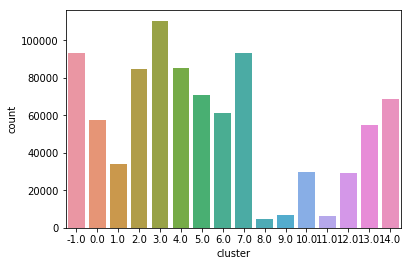

In [49]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

# General Population Distribution
labels1=pd.DataFrame(prediction)
labels1.columns=['cluster']

# Cluster-1 includes those rows having too many NAs
labels2=pd.DataFrame(-1*np.ones([azdias_missing.shape[0],1]))
labels2.columns=['cluster']

labels=pd.concat([labels1,labels2],axis=0)

sns.countplot(x='cluster',data=labels)

In [51]:

nas = pd.read_csv('../data/CUSTOMERS_Subset.csv',delimiter=';')

nas=clean_data(nas)
na_count=pd.DataFrame(nas.shape[1] - nas.count(axis=1))
na_count.columns=['na_count']
na_count=na_count[na_count['na_count']>=30]
customers_missing=nas.loc[na_count.index,:]

/opt/conda/lib/python3.6/site-packages/pandas/core/indexes/api.py:107: RuntimeWarning: '<' not supported between instances of 'float' and 'str', sort order is undefined for incomparable objects
  result = result.union(other)
/opt/conda/lib/python3.6/site-packages/pandas/core/frame.py:7397: RuntimeWarning: '<' not supported between instances of 'float' and 'str', sort order is undefined for incomparable objects
  index = _union_indexes(indexes)
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


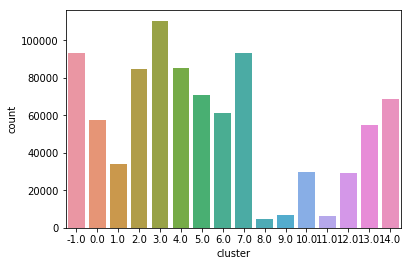

In [52]:
# Customer Data Distribution
labels2 = pd.DataFrame(labels2)
labels2.columns=['cluster']

labels3=pd.DataFrame(-1*np.ones([customers_missing.shape[0],1]))
labels3.columns=['cluster']

labels4=pd.concat([labels2,labels3],axis=0)
sns.countplot(x='cluster',data=labels)

In [53]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

labels1.index=azdias.index
azdias=pd.concat([azdias,labels1],axis=1)
cluster3=azdias.loc[azdias['cluster']==3,:]

In [54]:
cluster3=cluster3.iloc[:,1:78]
for a in cluster3.columns:
    print(cluster3[a].value_counts())

3.0    54791
4.0    44323
2.0     8382
1.0     2869
0.0      176
Name: ALTERSKATEGORIE_GROB, dtype: int64
1.0    63343
2.0    47198
Name: ANREDE_KZ, dtype: int64
2.0    31950
4.0    23184
3.0    18946
1.0    15041
5.0    13619
6.0     7801
Name: CJT_GESAMTTYP, dtype: int64
5.0    64956
4.0    39152
3.0     5894
2.0      507
1.0       32
Name: FINANZ_MINIMALIST, dtype: int64
1.0    49018
2.0    37817
3.0    17355
4.0     5381
5.0      970
Name: FINANZ_SPARER, dtype: int64
5.0    43955
4.0    42699
3.0    15531
1.0     4975
2.0     3381
Name: FINANZ_VORSORGER, dtype: int64
2.0    30897
1.0    27456
3.0    23941
4.0    21686
5.0     6561
Name: FINANZ_ANLEGER, dtype: int64
1.0    41106
2.0    36379
3.0    25232
4.0     4194
5.0     3630
Name: FINANZ_UNAUFFAELLIGER, dtype: int64
1.0    46477
2.0    36378
3.0    19557
4.0     7376
5.0      753
Name: FINANZ_HAUSBAUER, dtype: int64
6.0    62530
2.0    29068
3.0    10473
5.0     6551
4.0     1294
1.0      625
Name: FINANZTYP, dtype: int64
0    

In [55]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

cluster0 = azdias.loc[azdias['cluster']==0,:]

In [56]:
cluster0=cluster0.iloc[:,1:78]
for a in cluster0.columns:
    print(cluster0[a].value_counts())

3.0    27403
4.0    20526
2.0     6911
1.0     2672
0.0       93
Name: ALTERSKATEGORIE_GROB, dtype: int64
2.0    57603
1.0        2
Name: ANREDE_KZ, dtype: int64
2.0    15942
4.0    11722
6.0    10710
3.0     7202
5.0     6440
1.0     5589
Name: CJT_GESAMTTYP, dtype: int64
4.0    24578
5.0    23098
3.0     7408
2.0     2010
1.0      511
Name: FINANZ_MINIMALIST, dtype: int64
1.0    24951
2.0    18257
3.0     8535
4.0     4860
5.0     1002
Name: FINANZ_SPARER, dtype: int64
5.0    23445
4.0    18708
3.0     5845
2.0     4951
1.0     4656
Name: FINANZ_VORSORGER, dtype: int64
1.0    19510
2.0    13081
3.0    11944
4.0    10502
5.0     2568
Name: FINANZ_ANLEGER, dtype: int64
2.0    18840
1.0    15118
3.0    13308
5.0     6200
4.0     4139
Name: FINANZ_UNAUFFAELLIGER, dtype: int64
1.0    20169
2.0    14707
3.0    14170
4.0     6731
5.0     1828
Name: FINANZ_HAUSBAUER, dtype: int64
6.0    22270
2.0    18109
3.0     6278
5.0     5223
4.0     3589
1.0     2136
Name: FINANZTYP, dtype: int64
1    

In [59]:
def plot_scaled_comparison(df_sample, kmeans, cluster):
    X = pd.DataFrame.from_dict(dict(zip(df_sample.columns,
pca.inverse_transform(kmeans.cluster_centers_[cluster]))), orient='index').rename(
columns={0: 'feature_values'}).sort_values('feature_values', ascending=False)
    X['feature_values_abs'] = abs(X['feature_values'])
    pd.concat((X['feature_values'][:10], X['feature_values'][-10:]), axis=0).plot(kind='barh');

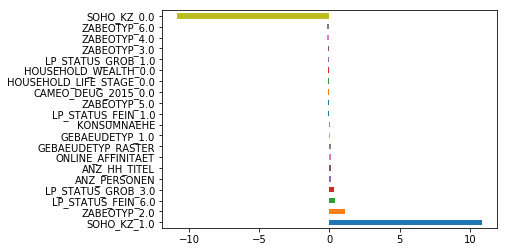

In [61]:
plot_scaled_comparison(customers, kmeans, 14)

### Discussion 3.3: Compare Customer Data to Demographics Data

Segments of the population that are relatively popular with the mail-order company is Cluster 3. Cluster 3 is mostly middle-aged and elderly people - people between the ages of 30 and 60 years old, who are also typically house owners. Household income is average and they individuals are likely middle class and have children. The unemployment level in this community is relatively low.

The mail-order company is relatively unpopular to Cluster 0 which is made up of also middle aged and elderly single males between 30 and 60 years old but who are low income earners and are classified as Minimal-Returners.

Note - Cluster -1 are customers with too many unknown information. The dataset has more of this kind of customers (26%) compared with the population density (10%). They are 'overrepresented.'